In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("Unemployment in India.csv")
print(df.head())
print(df.shape)
print(df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
(768, 7)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data column

In [6]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [9]:
df.columns=df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [13]:
df['Date']=pd.to_datetime(df['Date'])

In [14]:
print(df['Estimated Unemployment Rate (%)'].mean())

11.787945945945946


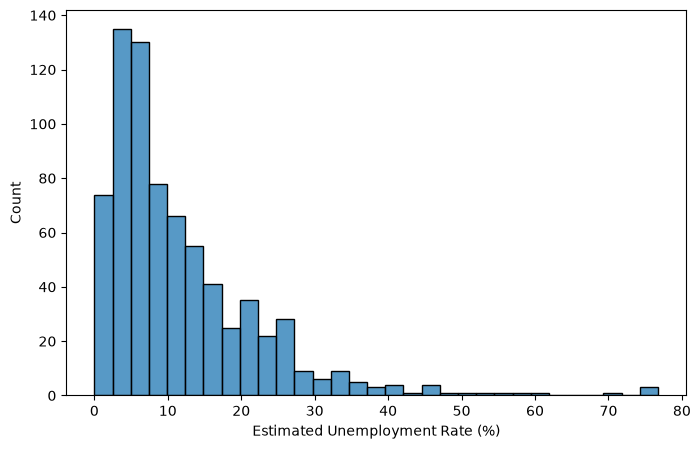

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated Unemployment Rate (%)'])
plt.show()

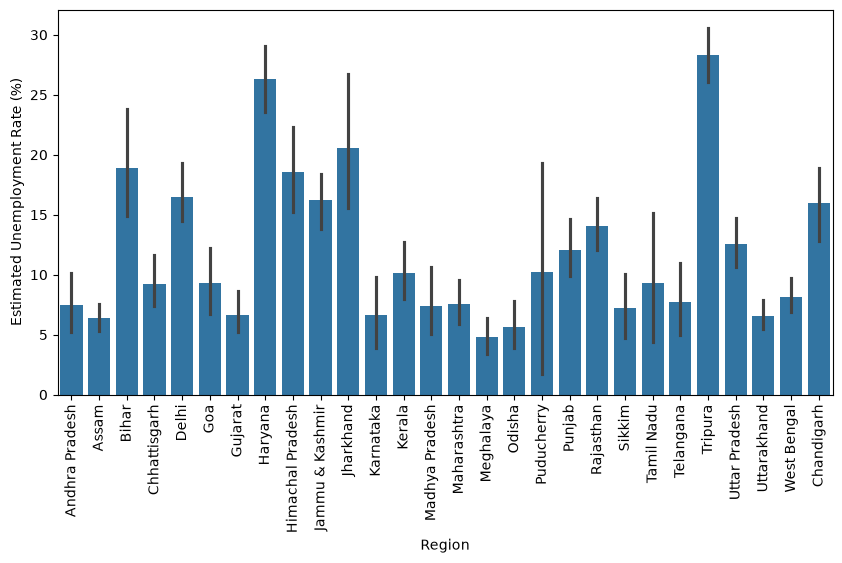

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
x='Region',
y='Estimated Unemployment Rate (%)',
data=df
)

plt.xticks(rotation=90)
plt.show()

In [22]:
covid = df[df['Date'] >= '2020-03-01']
covid['Estimated Unemployment Rate (%)'].mean()

np.float64(17.774362745098042)

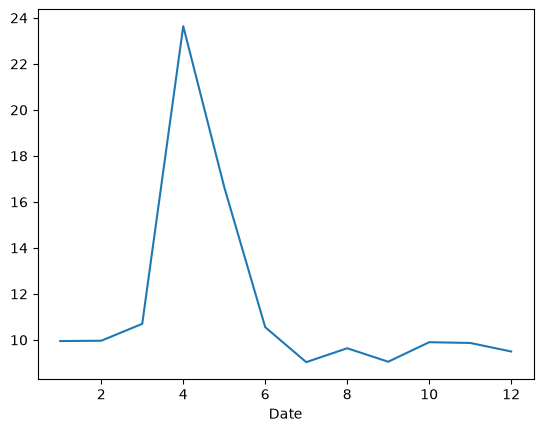

In [23]:
monthly = df.groupby(df['Date'].dt.month)[
'Estimated Unemployment Rate (%)'
].mean()

monthly.plot()
plt.show()

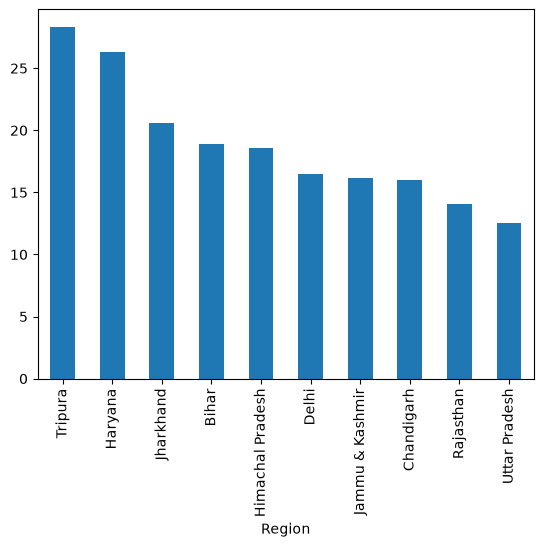

In [25]:
top_states = (
df.groupby('Region')
['Estimated Unemployment Rate (%)']
.mean()
.sort_values(ascending=False)
.head(10)
)

top_states.plot(kind='bar')
plt.show()

In [26]:
before = df[df['Date'] < '2020-03-01']
after = df[df['Date'] >= '2020-03-01']

print(before['Estimated Unemployment Rate (%)'].mean())
print(after['Estimated Unemployment Rate (%)'].mean())

9.509533582089553
17.774362745098042


In [43]:
df2= pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df2.groupby('Region.1')
df2.columns = df2.columns.str.strip()
df2.groupby('Region.1')['Estimated Unemployment Rate (%)'].mean()


Region.1
East         13.916000
North        15.889620
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64

In [45]:
df2.groupby('Region.1')
df2.groupby('Region.1')['Estimated Employed'].mean()

Region.1
East         1.960237e+07
North        1.307249e+07
Northeast    3.617106e+06
South        1.404059e+07
West         1.862351e+07
Name: Estimated Employed, dtype: float64

In [46]:
df2.groupby('Region')
['Estimated Unemployment Rate (%)']
df2.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values()


Region
Meghalaya            3.866000
Assam                4.856000
Gujarat              6.376000
Odisha               6.462000
Telangana            6.833000
Madhya Pradesh       6.854000
Karnataka            7.668000
Chhattisgarh         7.819000
Maharashtra          7.979000
Andhra Pradesh       8.664000
Kerala               9.434000
Uttar Pradesh        9.737000
Sikkim               9.792500
West Bengal         10.192000
Uttarakhand         11.156000
Punjab              11.981000
Goa                 12.167000
Tamil Nadu          12.187000
Rajasthan           15.868000
Himachal Pradesh    16.065000
Jammu & Kashmir     16.477778
Puducherry          17.942000
Delhi               18.414000
Bihar               19.471000
Jharkhand           19.539000
Tripura             25.055000
Haryana             27.477000
Name: Estimated Unemployment Rate (%), dtype: float64